In [1]:
import xarray as xr
import xagg
import geopandas as gpd
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
sns.set_style('white')

# Combining 2m Temperature Absolute Error at 24 hour lead time with Maryland Counties

## Read in forecast, analysis, and climatology data and compute anomalies

In [2]:
# Forecast (00z initialization time, 24 hour lead time)
fc_files = sorted(glob.glob('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/fc/0.125/t2m/00/24/2023/07/*.nc'))
ds_fc = xr.open_mfdataset(fc_files)

# Analysis
an_files = sorted(glob.glob('/glade/derecho/scratch/dcalhoun/ecmwf/ifs/an/0.125/t2m/2023/07/*/*.nc'))
ds_an = xr.open_mfdataset(an_files)

# Climatology
clim_file = '/glade/derecho/scratch/dcalhoun/ecmwf/era5/era5_2t_climatology_1991_2020_sorted.nc'
ds_clim = xr.open_dataset(clim_file)

# Ensure all times present in both fc and an
common_times = np.intersect1d(ds_fc['t2m'].time.values, ds_an['t2m'].time.values)
ds_fc = ds_fc.sel(time=common_times)
ds_an = ds_an.sel(time=common_times)

ds_fc = ds_fc.sel(time=~((ds_fc.time.dt.month == 2) & (ds_fc.time.dt.day == 29)))
ds_an = ds_an.sel(time=~((ds_an.time.dt.month == 2) & (ds_an.time.dt.day == 29)))

# Interpolate the climatology to the same grid as the forecast and analysis
ds_clim = ds_clim.sel(latitude=slice(ds_fc.latitude.min(), ds_fc.latitude.max()), longitude=slice(ds_fc.longitude.min(), ds_fc.longitude.max())).interp(latitude = ds_fc.latitude.values, longitude = ds_fc.longitude.values, method='nearest')

# Calculate anomalies
ds_clim = ds_clim.sel(time=pd.to_datetime(ds_fc.time.dt.strftime('2017-%m-%d')).dayofyear) # align climatology to forecast data
ds_fc['t2m'] = (['time', 'latitude', 'longitude'], ds_fc['t2m'].values - ds_clim['2t'].values)
ds_an['t2m'] = (['time', 'latitude', 'longitude'], ds_an['t2m'].values - ds_clim['2t'].values)

In [3]:
ds_fc

<xarray.Dataset> Size: 2MB
Dimensions:    (time: 30, latitude: 81, longitude: 121)
Coordinates:
  * longitude  (longitude) float32 484B -85.0 -84.88 -84.75 ... -70.12 -70.0
  * latitude   (latitude) float32 324B 45.0 44.88 44.75 ... 35.25 35.12 35.0
  * time       (time) datetime64[ns] 240B 2023-07-02 2023-07-03 ... 2023-07-31
Data variables:
    t2m        (time, latitude, longitude) float64 2MB 5.558 5.467 ... 0.09521
Attributes:
    Conventions:  CF-1.6
    history:      2024-11-24 03:29:47 GMT by grib_to_netcdf-2.25.0: grib_to_n...

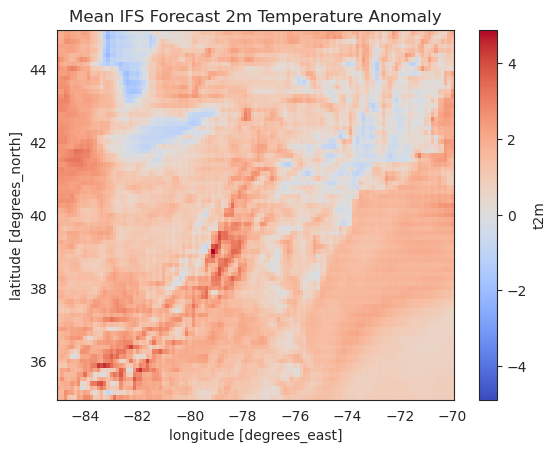

In [4]:
ds_fc.t2m.mean(axis=0).plot(cmap='coolwarm')
plt.title('Mean IFS Forecast 2m Temperature Anomaly')
plt.show()

In [5]:
ds_an

<xarray.Dataset> Size: 2MB
Dimensions:    (time: 30, latitude: 81, longitude: 121)
Coordinates:
  * longitude  (longitude) float32 484B -85.0 -84.88 -84.75 ... -70.12 -70.0
  * latitude   (latitude) float32 324B 45.0 44.88 44.75 ... 35.25 35.12 35.0
  * time       (time) datetime64[ns] 240B 2023-07-02 2023-07-03 ... 2023-07-31
Data variables:
    t2m        (time, latitude, longitude) float64 2MB 6.813 6.697 ... -0.06523
Attributes:
    Conventions:  CF-1.6
    history:      2024-11-30 22:14:05 GMT by grib_to_netcdf-2.25.0: grib_to_n...

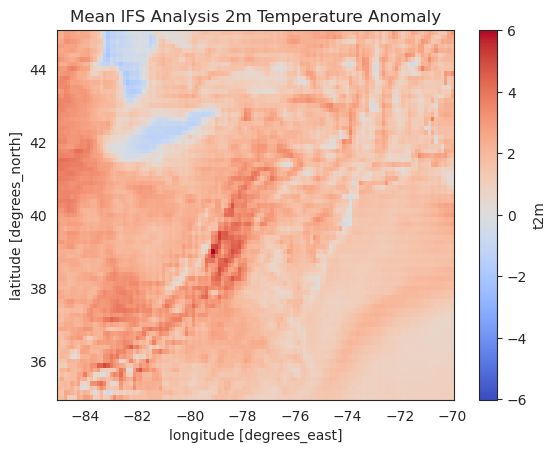

In [6]:
ds_an.t2m.mean(axis=0).plot(cmap='coolwarm')
plt.title('Mean IFS Analysis 2m Temperature Anomaly')
plt.show()

## Calculate Absolute Error

In [7]:
ds_abs_error = xr.Dataset({
                't2m_abs_error': (['time', 'latitude','longitude'], abs(ds_fc.t2m - ds_an.t2m).values)
                },
                coords = {
                    'time':(['time'], ds_fc.time.values),
                    'latitude' : (['latitude'], ds_fc.latitude.values),
                    'longitude' : (['longitude'], ds_fc.longitude.values)
                })      

In [8]:
ds_abs_error

<xarray.Dataset> Size: 2MB
Dimensions:        (time: 30, latitude: 81, longitude: 121)
Coordinates:
  * time           (time) datetime64[ns] 240B 2023-07-02 ... 2023-07-31
  * latitude       (latitude) float32 324B 45.0 44.88 44.75 ... 35.25 35.12 35.0
  * longitude      (longitude) float32 484B -85.0 -84.88 -84.75 ... -70.12 -70.0
Data variables:
    t2m_abs_error  (time, latitude, longitude) float64 2MB 1.254 1.23 ... 0.1604

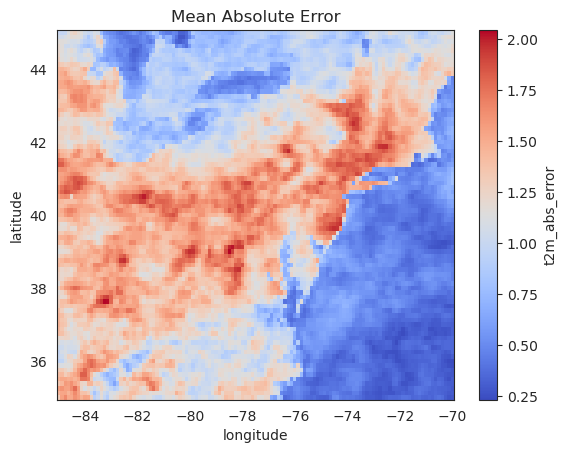

In [9]:
ds_abs_error.t2m_abs_error.mean(axis=0).plot(cmap='coolwarm')
plt.title('Mean Absolute Error')
plt.show()

## Aggregate

In [10]:
# Read in the shapefile
shapefile_path = '/glade/derecho/scratch/dcalhoun/census/shapefiles/nhgis0001_shapefile_tl2023_us_county_2023'
gdf = gpd.read_file(shapefile_path, columns=['GEOID', 'STATEFP', 'geometry']).to_crs('WGS84')
gdf.head()

,GEOID,STATEFP,geometry
0,01001,01,"POLYGON ((-86.41117 32.40993, -86.41615 32.407..."
1,01003,01,"MULTIPOLYGON (((-87.55444 30.27956, -87.55458 ..."
2,01005,01,"POLYGON ((-85.05603 32.06305, -85.05593 32.063..."
3,01007,01,"POLYGON ((-87.0258 33.21716, -87.02572 33.2097..."
4,01009,01,"POLYGON ((-86.44413 34.25911, -86.44433 34.256..."


In [11]:
# Maryland only
gdf_md = gdf[gdf['STATEFP'] == '24'][['GEOID', 'geometry']].reset_index(drop=True)
gdf_md

,GEOID,geometry
0,24001,"POLYGON ((-78.34283 39.72226, -78.34273 39.722..."
1,24003,"MULTIPOLYGON (((-76.53323 38.8869, -76.53327 3..."
2,24005,"MULTIPOLYGON (((-76.50015 39.24931, -76.49987 ..."
3,24009,"MULTIPOLYGON (((-76.45425 38.3225, -76.45405 3..."
4,24011,"POLYGON ((-75.72279 38.82985, -75.72236 38.824..."
5,24013,"POLYGON ((-76.88227 39.35019, -76.88225 39.350..."
6,24015,"MULTIPOLYGON (((-75.8472 39.36903, -75.84737 3..."
7,24017,"MULTIPOLYGON (((-76.85986 38.26792, -76.85976 ..."
8,24019,"MULTIPOLYGON (((-76.09107 38.1327, -76.08913 3..."
9,24021,"POLYGON ((-77.16808 39.35396, -77.16817 39.353..."


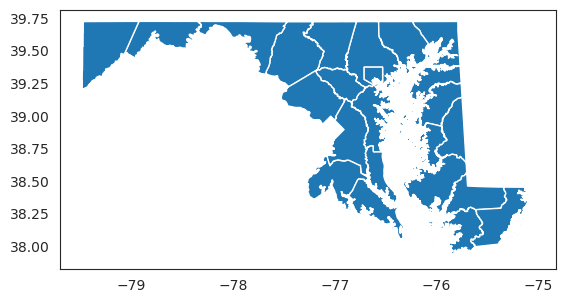

In [12]:
gdf_md.plot()
plt.show()

In [13]:
# Aggregate
dfs = []
dates = pd.to_datetime(ds_abs_error.time.values)
for i, date in enumerate(dates):
    day = date.strftime('%d')
    hour = date.strftime('%H')
    dirname = '/glade/derecho/scratch/dcalhoun/aggregated/county/Maryland/ifs/0.125/t2m/00/24/2023/07'
    os.makedirs(dirname, exist_ok=True)
    filename = os.path.join(dirname, f'ifs_abs_error_t2m_2023_07_{day}_{hour}z.csv')
    weightmap = xagg.pixel_overlaps(ds_abs_error.sel(time=date), gdf_md, silent=True)
    aggregated = xagg.aggregate(ds_abs_error.sel(time=date), weightmap, silent=True)
    df = aggregated.to_dataframe()
    df['time'] = date.strftime('%Y-%m-%d-%H')
    df.reset_index(inplace=True, drop=True)
    cols = df.columns.tolist()
    df = df[cols[0:1] + cols[-1:] + cols[1:-1]] # Reorder columns
    df.to_csv(filename)
    dfs.append(df)
dfs[0]

,GEOID,time,t2m_abs_error
0,24001,2023-07-02-00,1.704608
1,24003,2023-07-02-00,0.973750
2,24005,2023-07-02-00,0.822309
3,24009,2023-07-02-00,1.148691
4,24011,2023-07-02-00,1.293019
5,24013,2023-07-02-00,0.493152
6,24015,2023-07-02-00,1.026146
7,24017,2023-07-02-00,0.453405
8,24019,2023-07-02-00,1.053451
9,24021,2023-07-02-00,0.711162


## Get Census Variables

In [14]:
# Read in the census data
census_files = sorted(glob.glob('/glade/derecho/scratch/dcalhoun/census/data/acs_5yr_2023/county/Maryland/*.csv'))
dataframes = []
df = None
for i, census_file in enumerate(census_files):
    if i != len(census_files) - 1:
        df = pd.read_csv(census_file)
        ncols = len(df.columns)
        df = pd.read_csv(census_file, usecols=range(ncols - 4))
        dataframes.append(df)
    else:
        df = pd.read_csv(census_file)
        dataframes.append(df)
df_census = pd.concat(dataframes, axis=1)

# Clean up the census data
df_census.drop(columns=['Unnamed: 0'], inplace=True) # Drop duplicate index column
df_census['GEOID'] = df_census['GEO_ID'].str.slice(-5) # Extract the shortened GEOID from the GEO_ID column
df_census.drop(columns=['GEO_ID'], inplace=True) # Drop the original GEO_ID column
cols = df_census.columns.tolist()
new_order = cols[-3:] + cols[:-3]
df_census = df_census[new_order] # Reorder columns
df_census.rename(columns={'state': 'STATEFP', 'county': 'COUNTYFP'}, inplace=True) # Rename columns

# Split estimates and margins of error into separate DataFrames
retain_columns = ['GEOID', 'NAME', 'STATEFP', 'COUNTYFP']
df_census_est = df_census[[col for col in df_census.columns if col not in retain_columns and col.endswith('E')]].copy()
df_census_moe = df_census[[col for col in df_census.columns if col not in retain_columns and col.endswith('M')]].copy()
df_census_est.columns = df_census_est.columns.str[:-1]
df_census_moe.columns = df_census_moe.columns.str[:-1]
df_census_est = pd.concat([df_census[retain_columns], df_census_est], axis=1)
df_census_moe = pd.concat([df_census[retain_columns], df_census_moe], axis=1)

df_census_est.head()

,GEOID,NAME,STATEFP,COUNTYFP,B01001_001,B01001_002,B01001_003,B01001_004,B01001_005,B01001_006,...,B23025_007,B25001_001,B25002_001,B25002_002,B25002_003,B25003_001,B25003_002,B25003_003,B25064_001,B25077_001
0,24001,"Allegany County, Maryland",24,1,67762,35357,1588,1900,1671,1093,...,29483,32810,32810,27436,5374,27436,19294,8142,786,149200
1,24003,"Anne Arundel County, Maryland",24,3,590936,292506,18141,18728,19943,11393,...,144719,234843,234843,223602,11241,223602,167618,55984,1990,450300
2,24005,"Baltimore County, Maryland",24,5,849586,404133,24970,26150,27069,16648,...,233100,350296,350296,330151,20145,330151,218994,111157,1566,330000
3,24009,"Calvert County, Maryland",24,9,93791,46707,2543,3457,3108,2085,...,24305,35960,35960,33485,2475,33485,29184,4301,1701,440200
4,24011,"Caroline County, Maryland",24,11,33406,16442,1048,1318,939,733,...,9789,13516,13516,12181,1335,12181,8753,3428,1070,272400


## Combine error and census estimates

In [15]:
joined_dfs = []
for df in dfs:
    joined = pd.concat([df.copy().set_index('GEOID'), df_census_est.copy().set_index('GEOID')], axis=1)
    joined_dfs.append(joined)
joined_df = pd.concat(joined_dfs)
joined_df.head()

,time,t2m_abs_error,NAME,STATEFP,COUNTYFP,B01001_001,B01001_002,B01001_003,B01001_004,B01001_005,...,B23025_007,B25001_001,B25002_001,B25002_002,B25002_003,B25003_001,B25003_002,B25003_003,B25064_001,B25077_001
GEOID,,,,,,,,,,,,,,,,,,,,,
24001,2023-07-02-00,1.704608,"Allegany County, Maryland",24,1,67762,35357,1588,1900,1671,...,29483,32810,32810,27436,5374,27436,19294,8142,786,149200
24003,2023-07-02-00,0.973750,"Anne Arundel County, Maryland",24,3,590936,292506,18141,18728,19943,...,144719,234843,234843,223602,11241,223602,167618,55984,1990,450300
24005,2023-07-02-00,0.822309,"Baltimore County, Maryland",24,5,849586,404133,24970,26150,27069,...,233100,350296,350296,330151,20145,330151,218994,111157,1566,330000
24009,2023-07-02-00,1.148691,"Calvert County, Maryland",24,9,93791,46707,2543,3457,3108,...,24305,35960,35960,33485,2475,33485,29184,4301,1701,440200
24011,2023-07-02-00,1.293019,"Caroline County, Maryland",24,11,33406,16442,1048,1318,939,...,9789,13516,13516,12181,1335,12181,8753,3428,1070,272400


In [16]:
joined_df.describe()

,t2m_abs_error,STATEFP,COUNTYFP,B01001_001,B01001_002,B01001_003,B01001_004,B01001_005,B01001_006,B01001_007,...,B23025_007,B25001_001,B25002_001,B25002_002,B25002_003,B25003_001,B25003_002,B25003_003,B25064_001,B25077_001
count,720.000000,720.0,720.000000,7.200000e+02,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,...,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000
mean,1.285357,24.0,44.958333,2.571141e+05,125086.625000,7621.416667,8051.250000,8499.541667,5101.791667,3254.958333,...,67733.583333,106063.833333,106063.833333,97479.583333,8584.250000,97479.583333,65779.250000,31700.333333,1414.541667,350737.500000
std,0.882971,0.0,97.955091,3.064078e+05,147714.333905,9410.147758,9683.947878,10134.417689,6019.839730,3925.483316,...,76509.539093,121399.385457,121399.385457,115122.007414,10329.101278,115122.007414,73132.621605,44292.986146,383.662532,114803.372372
min,0.119428,24.0,1.000000,1.926500e+04,9301.000000,389.000000,522.000000,323.000000,336.000000,299.000000,...,6833.000000,10326.000000,10326.000000,8296.000000,1335.000000,8296.000000,5710.000000,2383.000000,710.000000,149200.000000
25%,0.655531,24.0,14.500000,4.764000e+04,23541.250000,1128.250000,1282.000000,1486.750000,821.500000,479.000000,...,13846.750000,21195.000000,21195.000000,18780.500000,2810.500000,18780.500000,14925.000000,4395.500000,1133.000000,267375.000000
50%,1.101146,24.0,26.000000,1.093690e+05,54725.500000,3407.000000,4033.000000,3595.500000,2413.000000,1783.000000,...,30755.000000,51331.500000,51331.500000,40957.500000,4236.500000,40957.500000,30288.500000,10774.500000,1368.500000,357700.000000
75%,1.697323,24.0,37.500000,2.937348e+05,145190.500000,8654.000000,9539.000000,10691.000000,6351.250000,3663.000000,...,70636.000000,110982.250000,110982.250000,106371.750000,7311.750000,106371.750000,81470.250000,26025.000000,1702.250000,414225.000000
max,6.037609,24.0,510.000000,1.057586e+06,515257.000000,31581.000000,34597.000000,36450.000000,22197.000000,13720.000000,...,253298.000000,405127.000000,405127.000000,387881.000000,43023.000000,387881.000000,253448.000000,134433.000000,2038.000000,615200.000000


In [17]:
joined_df['Population Quartile'] = pd.qcut(joined_df['B01001_001'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

joined_df['Percent White'] = joined_df['B02001_002'] / joined_df['B02001_001'] * 100
joined_df['Percent Black'] = joined_df['B02001_003'] / joined_df['B02001_001'] * 100
joined_df['Percent Below Poverty'] = joined_df['B17001_002']/joined_df['B17001_001']

joined_df['Percent White Quartile'] = pd.qcut(joined_df['Percent White'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
joined_df['Percent Black Quartile'] = pd.qcut(joined_df['Percent Black'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
joined_df['Percent Below Poverty Quartile'] = pd.qcut(joined_df['Percent Below Poverty'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

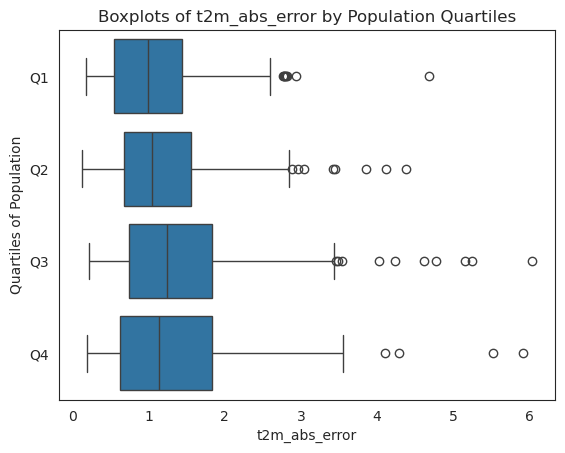

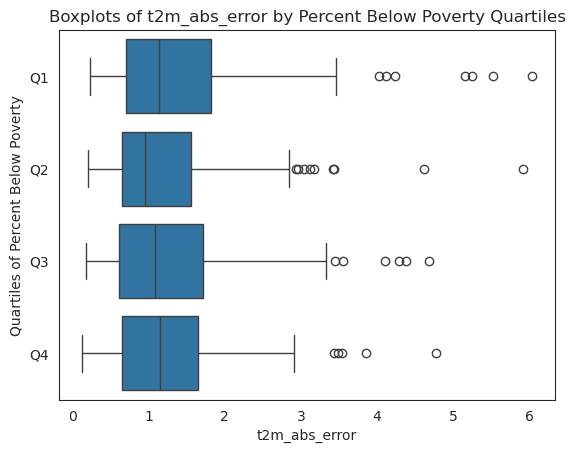

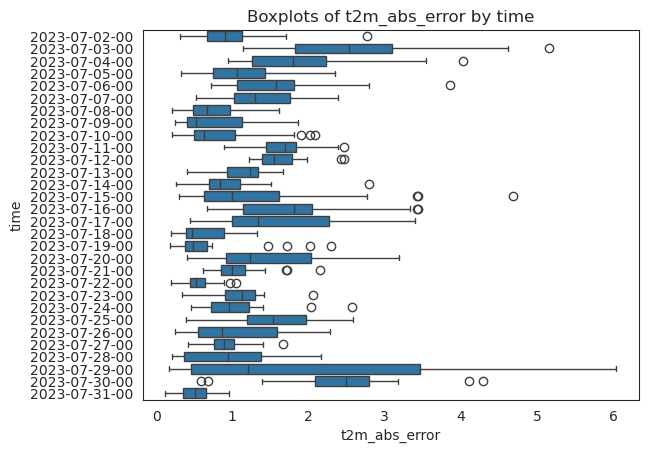

In [18]:
sns.boxplot(data=joined_df, y='Population Quartile', x='t2m_abs_error')
plt.title('Boxplots of t2m_abs_error by Population Quartiles')
plt.ylabel('Quartiles of Population')
plt.xlabel('t2m_abs_error')
plt.show()

sns.boxplot(data=joined_df, y='Percent Below Poverty Quartile', x='t2m_abs_error')
plt.title('Boxplots of t2m_abs_error by Percent Below Poverty Quartiles')
plt.ylabel('Quartiles of Percent Below Poverty')
plt.xlabel('t2m_abs_error')
plt.show()

sns.boxplot(data=joined_df, y='time', x='t2m_abs_error')
plt.title('Boxplots of t2m_abs_error by time')
plt.ylabel('time')
plt.xlabel('t2m_abs_error')
plt.show()

# Combine with shapefiles for plotting

In [19]:
gdfs = []
for df in dfs:
    gdf = pd.concat([df.copy().set_index('GEOID'), df_census_est.copy().set_index('GEOID'), gdf_md.copy().set_index('GEOID')], axis=1)
    gdfs.append(gdf)
gdf_error = gpd.GeoDataFrame(pd.concat(gdfs))
gdf_error

,time,t2m_abs_error,NAME,STATEFP,COUNTYFP,B01001_001,B01001_002,B01001_003,B01001_004,B01001_005,...,B25001_001,B25002_001,B25002_002,B25002_003,B25003_001,B25003_002,B25003_003,B25064_001,B25077_001,geometry
GEOID,,,,,,,,,,,,,,,,,,,,,
24001,2023-07-02-00,1.704608,"Allegany County, Maryland",24,1,67762,35357,1588,1900,1671,...,32810,32810,27436,5374,27436,19294,8142,786,149200,"POLYGON ((-78.34283 39.72226, -78.34273 39.722..."
24003,2023-07-02-00,0.973750,"Anne Arundel County, Maryland",24,3,590936,292506,18141,18728,19943,...,234843,234843,223602,11241,223602,167618,55984,1990,450300,"MULTIPOLYGON (((-76.53323 38.8869, -76.53327 3..."
24005,2023-07-02-00,0.822309,"Baltimore County, Maryland",24,5,849586,404133,24970,26150,27069,...,350296,350296,330151,20145,330151,218994,111157,1566,330000,"MULTIPOLYGON (((-76.50015 39.24931, -76.49987 ..."
24009,2023-07-02-00,1.148691,"Calvert County, Maryland",24,9,93791,46707,2543,3457,3108,...,35960,35960,33485,2475,33485,29184,4301,1701,440200,"MULTIPOLYGON (((-76.45425 38.3225, -76.45405 3..."
24011,2023-07-02-00,1.293019,"Caroline County, Maryland",24,11,33406,16442,1048,1318,939,...,13516,13516,12181,1335,12181,8753,3428,1070,272400,"POLYGON ((-75.72279 38.82985, -75.72236 38.824..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24041,2023-07-31-00,0.570553,"Talbot County, Maryland",24,41,37707,18115,859,1174,1105,...,19671,19671,16211,3460,16211,11784,4427,1248,398300,"MULTIPOLYGON (((-76.08869 38.62277, -76.08847 ..."
24043,2023-07-31-00,0.463176,"Washington County, Maryland",24,43,155033,78714,4306,4831,4847,...,63965,63965,59411,4554,59411,39145,20266,1100,275900,"POLYGON ((-77.67716 39.32453, -77.67735 39.324..."
24045,2023-07-31-00,0.953192,"Wicomico County, Maryland",24,45,104117,49797,3227,3373,3377,...,43925,43925,40034,3891,40034,24294,15740,1238,238900,"MULTIPOLYGON (((-75.87579 38.33087, -75.87589 ..."


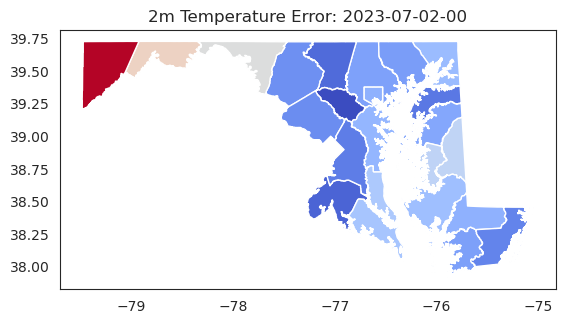

In [20]:
gdf_error[gdf_error['time'] == gdf_error['time'].iloc[0]].plot(column='t2m_abs_error', cmap='coolwarm')
plt.title(f'2m Temperature Error: {gdf_error['time'].values[0]}')
plt.show()